# Phase 2 — Exploratory Data Analysis

EV Smart-Charging Advisor: understand daily/weekly/seasonal price and
renewable-share patterns in the cleaned SMARD dataset, and identify which
features matter for the Phase 3 forecasting model.

Data: `data/processed/smard_market_data_clean.csv` — hourly electricity
price (day-ahead, DE-LU), grid load, and generation by source for Germany,
2024-07-14 through the present. See `src/clean_data.py` for how this was
derived from the raw SMARD pulls (older history was dropped: SMARD's
pre-mid-2024 chunking was sparse/misaligned across filters and unusable for
modeling).

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv("../data/processed/smard_market_data_clean.csv", parse_dates=["datetime"])
df = df.set_index("datetime")
df.index = df.index.tz_convert("Europe/Berlin")  # local time is what matters for daily/weekly patterns
df.shape

(17683, 14)

## 1. Sanity check: nulls and gaps

In [2]:
print("Null counts:")
print(df.isnull().sum())
print()

full_range = pd.date_range(df.index.min(), df.index.max(), freq="h", tz=df.index.tz)
missing = full_range.difference(df.index)
print(f"Missing hours in range: {len(missing)}")
print(f"Date range: {df.index.min()} to {df.index.max()}  ({(df.index.max()-df.index.min()).days} days)")

Null counts:
price_eur_mwh        0
load_mw              0
wind_onshore_mw      0
wind_offshore_mw     0
solar_mw             0
hydro_mw             0
biomass_mw           0
lignite_mw           0
hard_coal_mw         0
natural_gas_mw       0
nuclear_mw           0
pumped_storage_mw    0
renewable_mw         0
renewable_share      0
dtype: int64

Missing hours in range: 0
Date range: 2024-07-15 00:00:00+02:00 to 2026-07-21 18:00:00+02:00  (736 days)


## 2. Price and renewable share over time

Note: `renewable_share` here is renewable generation ÷ grid load, computed
in `clean_data.py`. It can exceed 1.0 during periods when Germany is a net
exporter (renewable output higher than domestic demand) — that's real, not
a bug, but worth keeping in mind when interpreting it as a literal "share."


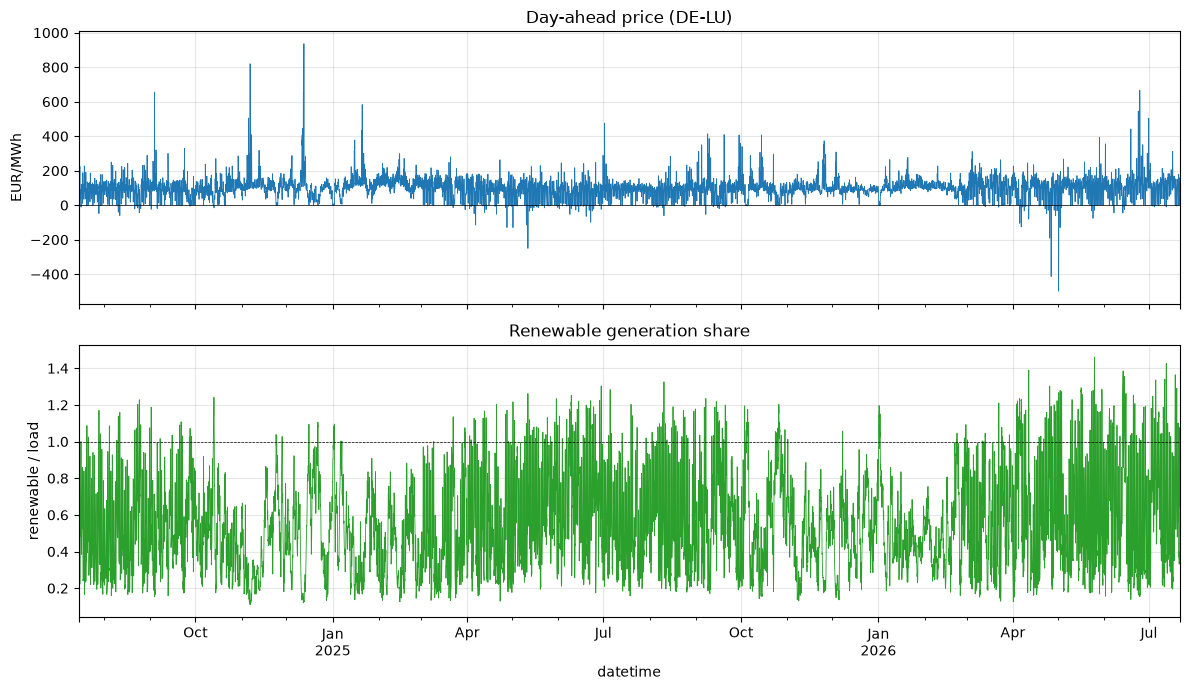

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
df["price_eur_mwh"].plot(ax=axes[0], color="#1f77b4", linewidth=0.6)
axes[0].set_ylabel("EUR/MWh")
axes[0].set_title("Day-ahead price (DE-LU)")
axes[0].axhline(0, color="black", linewidth=0.5)

df["renewable_share"].plot(ax=axes[1], color="#2ca02c", linewidth=0.6)
axes[1].set_ylabel("renewable / load")
axes[1].set_title("Renewable generation share")
axes[1].axhline(1.0, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("figures/figures_price_renewable_timeseries.png", dpi=110)
plt.show()

## 3. Patterns by hour-of-day

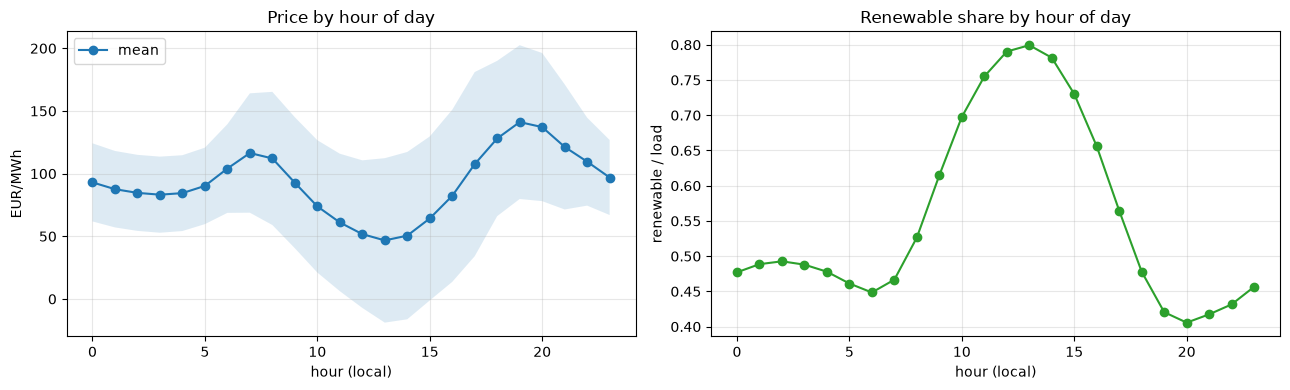

            mean   median        std
hour                                
0      93.030529   95.700  31.169038
1      87.597476   90.290  30.498254
2      84.660041   88.040  30.339207
3      83.211533   87.090  30.358697
4      84.453053   88.610  30.245481
5      90.225848   93.700  30.503866
6     104.067123  107.000  35.357958
7     116.451099  116.010  47.617710
8     112.131777  109.940  53.127593
9      92.739986   94.600  52.250045
10     73.889498   81.060  52.797242
11     61.073324   69.930  54.829158
12     51.750882   59.140  58.873408
13     46.735739   48.000  65.599895
14     50.539783   54.900  66.743910
15     64.238046   71.000  65.405729
16     82.292320   85.000  68.649314
17    107.585563  104.250  73.460441
18    128.063107  118.820  61.939906
19    141.119185  130.980  61.346415
20    137.140571  127.225  59.087437
21    121.326087  117.545  49.914026
22    109.556658  108.700  35.087089
23     96.908845   98.810  29.924118


In [4]:
d = df.copy()
d["hour"] = d.index.hour

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hourly_price = d.groupby("hour")["price_eur_mwh"].agg(["mean", "median", "std"])
axes[0].plot(hourly_price.index, hourly_price["mean"], marker="o", label="mean")
axes[0].fill_between(hourly_price.index,
                      hourly_price["mean"] - hourly_price["std"],
                      hourly_price["mean"] + hourly_price["std"], alpha=0.15)
axes[0].set_title("Price by hour of day")
axes[0].set_xlabel("hour (local)")
axes[0].set_ylabel("EUR/MWh")
axes[0].legend()

hourly_share = d.groupby("hour")["renewable_share"].mean()
axes[1].plot(hourly_share.index, hourly_share, marker="o", color="#2ca02c")
axes[1].set_title("Renewable share by hour of day")
axes[1].set_xlabel("hour (local)")
axes[1].set_ylabel("renewable / load")

plt.tight_layout()
plt.savefig("figures/figures_hourly_patterns.png", dpi=110)
plt.show()

print(hourly_price)

## 4. Patterns by day-of-week

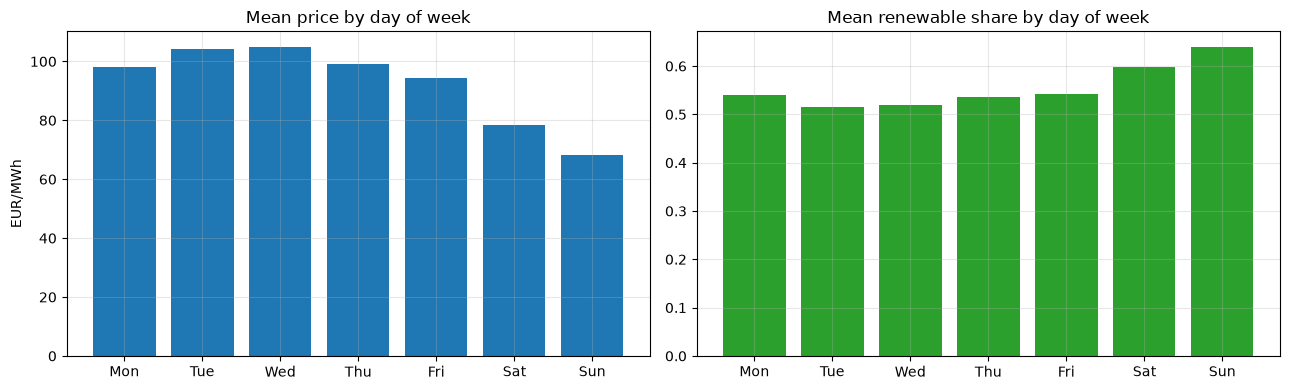

In [5]:
d["dow"] = d.index.dayofweek  # 0=Mon
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dow_price = d.groupby("dow")["price_eur_mwh"].mean()
axes[0].bar(dow_labels, dow_price.values, color="#1f77b4")
axes[0].set_title("Mean price by day of week")
axes[0].set_ylabel("EUR/MWh")

dow_share = d.groupby("dow")["renewable_share"].mean()
axes[1].bar(dow_labels, dow_share.values, color="#2ca02c")
axes[1].set_title("Mean renewable share by day of week")

plt.tight_layout()
plt.savefig("figures/figures_dow_patterns.png", dpi=110)
plt.show()

## 5. Seasonal (monthly) patterns

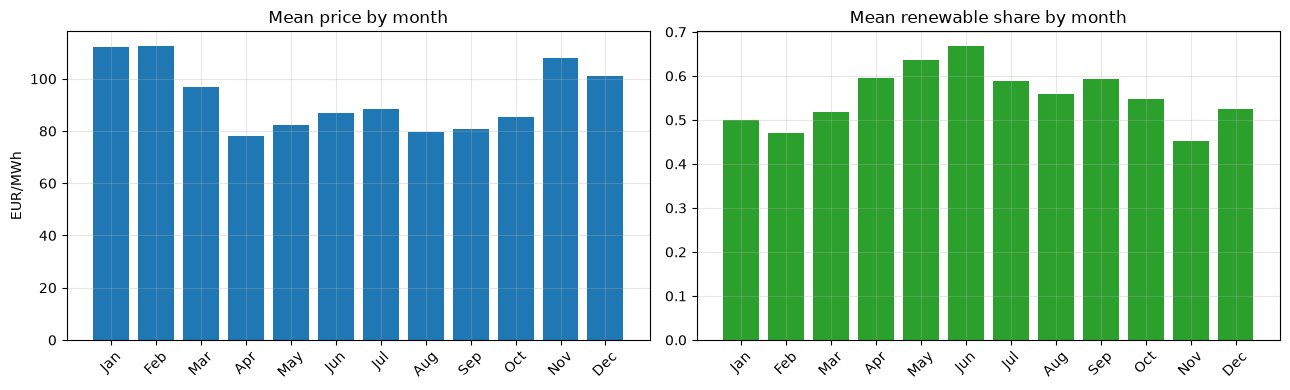

Note: this dataset spans ~2 years (2024-07 to now), so each calendar
month is only represented by 1-2 occurrences — treat seasonal
patterns here as suggestive, not statistically robust, until more
years of history accumulate.


In [6]:
d["month"] = d.index.month
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
month_price = d.groupby("month")["price_eur_mwh"].mean()
axes[0].bar([month_labels[m-1] for m in month_price.index], month_price.values, color="#1f77b4")
axes[0].set_title("Mean price by month")
axes[0].set_ylabel("EUR/MWh")
axes[0].tick_params(axis="x", rotation=45)

month_share = d.groupby("month")["renewable_share"].mean()
axes[1].bar([month_labels[m-1] for m in month_share.index], month_share.values, color="#2ca02c")
axes[1].set_title("Mean renewable share by month")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/figures_monthly_patterns.png", dpi=110)
plt.show()

print("Note: this dataset spans ~2 years (2024-07 to now), so each calendar")
print("month is only represented by 1-2 occurrences — treat seasonal")
print("patterns here as suggestive, not statistically robust, until more")
print("years of history accumulate.")

## 6. Price vs. renewable share correlation

renewable_share    -0.768699
solar_mw           -0.509290
wind_onshore_mw    -0.294785
wind_offshore_mw   -0.118065
load_mw             0.307743
price_eur_mwh       1.000000
Name: price_eur_mwh, dtype: float64


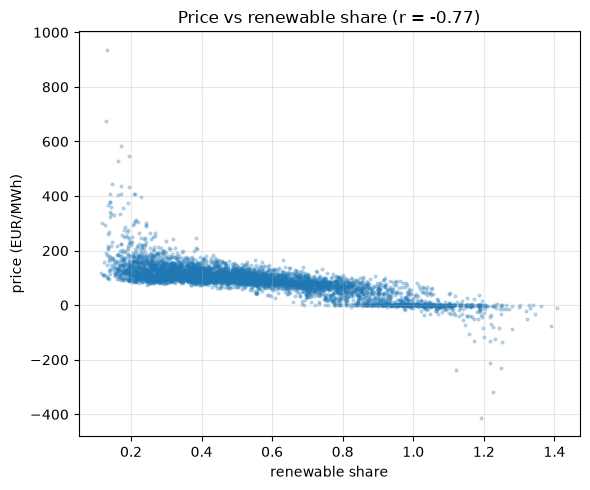

In [7]:
corr = df[["price_eur_mwh", "renewable_share", "load_mw", "wind_onshore_mw",
           "wind_offshore_mw", "solar_mw"]].corr()
print(corr["price_eur_mwh"].sort_values())

fig, ax = plt.subplots(figsize=(6, 5))
sample = df.sample(min(5000, len(df)), random_state=0)
ax.scatter(sample["renewable_share"], sample["price_eur_mwh"], s=4, alpha=0.25, color="#1f77b4")
ax.set_xlabel("renewable share")
ax.set_ylabel("price (EUR/MWh)")
ax.set_title(f"Price vs renewable share (r = {corr.loc['price_eur_mwh','renewable_share']:.2f})")
plt.tight_layout()
plt.savefig("figures/figures_price_vs_renewable_scatter.png", dpi=110)
plt.show()

**Finding:** price and renewable share are negatively correlated overall (r = -0.77), as expected — more renewable generation relative to load tends to push day-ahead price down, including into negative territory during oversupply. Among individual sources, solar_mw has the strongest negative correlation with price (r = -0.51), stronger than wind_onshore (-0.29) or wind_offshore (-0.12) — solar output is concentrated in a predictable midday window each day, which lines up tightly with the recurring midday price dip seen in the hour-of-day chart above, whereas wind is more diffuse across day/night and more variable day to day. `load_mw` is, as expected, positively correlated with price (r = 0.31).

## 7. Negative and extreme prices

Germany's day-ahead market allows negative prices during oversupply. These
are exactly the "charge now, it's practically free" windows this project
cares about, so worth checking how common they are.

Fraction of hours with negative price: 6.24%


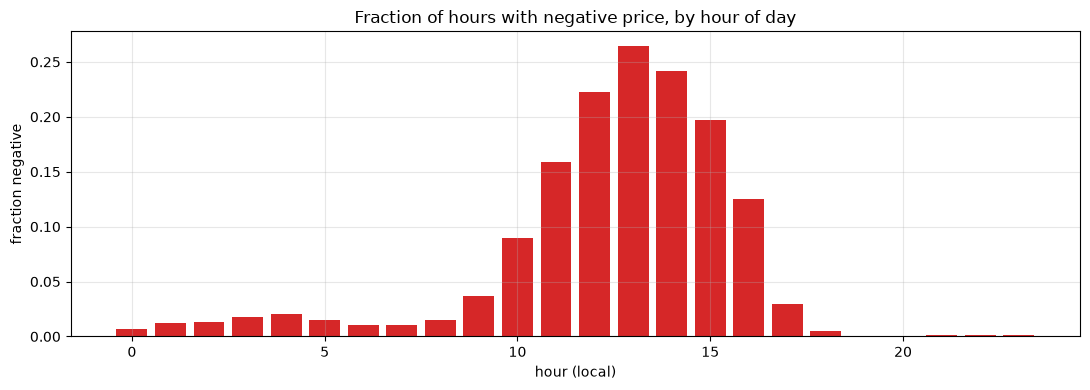

In [8]:
neg_frac = (df["price_eur_mwh"] < 0).mean()
print(f"Fraction of hours with negative price: {neg_frac:.2%}")

neg_by_hour = d.assign(is_neg=d["price_eur_mwh"] < 0).groupby("hour")["is_neg"].mean()
fig, ax = plt.subplots()
ax.bar(neg_by_hour.index, neg_by_hour.values, color="#d62728")
ax.set_title("Fraction of hours with negative price, by hour of day")
ax.set_xlabel("hour (local)")
ax.set_ylabel("fraction negative")
plt.tight_layout()
plt.savefig("figures/figures_negative_price_by_hour.png", dpi=110)
plt.show()

## 8. Feature set for Phase 3

Based on the patterns above, candidate features for the price/renewable-share
forecasting model:

- **Calendar features:** hour-of-day (cyclical sin/cos), day-of-week,
  weekend flag, month — hour-of-day is clearly the dominant driver of both
  price and renewable share (midday solar dip, evening peak).
- **Lag features:** price/load/renewable at t-1h, t-24h, t-168h (same hour
  yesterday / same hour last week) — day-of-week and hour-of-day patterns
  above justify both daily and weekly lags.
- **Rolling features:** 24h and 168h rolling mean/std of price and
  renewable share, to capture recent trend beyond a single lag point.
- **Weather-driven generation as leading signal:** wind_onshore_mw +
  wind_offshore_mw + solar_mw are strongly (negatively) correlated with
  price and are themselves forecastable a day or two out — since the model
  only needs to forecast 24-48h ahead, near-term generation forecasts (if
  available) would likely outperform pure price autoregression.
- **nuclear_mw dropped as a feature** — constant zero since the 2024
  phase-out, no predictive value.
